In [1]:
!pip install monai -q
!pip install albumentations -q
!pip install segmentation-models-pytorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 102.1 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible

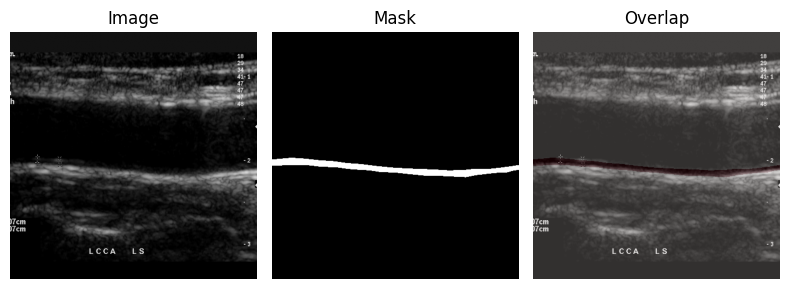

In [2]:
from matplotlib import pyplot as plt
import cv2
import numpy as np

img_path = "/kaggle/input/datasets/helloworldabc/cubs-k-fold-dataset/data_cropped/images/clin_0001_L.tiff"
msk_path = "/kaggle/input/datasets/helloworldabc/cubs-k-fold-dataset/data_cropped/masks/clin_0001_L_mask.png"

image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8, 6))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image, cmap="gray")
plt.imshow(mask, cmap="Reds", alpha=0.2)
plt.title("Overlap")
plt.axis("off")

plt.tight_layout()
plt.show()

In [3]:
from pathlib import Path

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset


class CUBSDataset(Dataset):
    def __init__(
        self,
        data_root,
        list_file,
        transform=None,
        image_dir_name="images",
        mask_dir_name="masks",
        image_ext=".tiff",
        mask_suffix="_mask.png",
    ):
        self.data_root = Path(data_root)
        self.list_file = Path(list_file)
        self.image_dir = self.data_root / image_dir_name
        self.mask_dir = self.data_root / mask_dir_name
        self.transform = transform
        self.image_ext = image_ext
        self.mask_suffix = mask_suffix

        if not self.image_dir.is_dir():
            raise FileNotFoundError(f"Image folder not found: {self.image_dir}")
        if not self.mask_dir.is_dir():
            raise FileNotFoundError(f"Mask folder not found: {self.mask_dir}")
        if not self.list_file.is_file():
            raise FileNotFoundError(f"List file not found: {self.list_file}")

        self.image_names = [
            line.strip()
            for line in self.list_file.read_text(encoding="utf-8").splitlines()
            if line.strip()
        ]

        if len(self.image_names) == 0:
            raise RuntimeError(f"Empty list file: {self.list_file}")

        self.images = []
        self.masks = []

        for name in self.image_names:
            stem = Path(name).stem

            image_path = self.image_dir / f"{stem}{self.image_ext}"
            mask_path = self.mask_dir / f"{stem}{self.mask_suffix}"

            if not image_path.is_file():
                raise FileNotFoundError(f"Image not found: {image_path}")
            if not mask_path.is_file():
                raise FileNotFoundError(f"Mask not found: {mask_path}")

            self.images.append(image_path)
            self.masks.append(mask_path)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = self.images[idx]
        mask_path = self.masks[idx]

        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise FileNotFoundError(f"Cannot read image: {image_path}")
        if mask is None:
            raise FileNotFoundError(f"Cannot read mask: {mask_path}")

        if image.shape[:2] != mask.shape[:2]:
            raise ValueError(
                f"Shape mismatch: {image_path.name} {image.shape} "
                f"!= {mask_path.name} {mask.shape}"
            )

        image = image.astype(np.float32)
        mask = (mask > 127).astype(np.uint8)

        if self.transform is not None:
            data = self.transform(image=image, mask=mask)
            image = data["image"]
            mask = data["mask"]

        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image).unsqueeze(0).float() / 255.0
        else:
            image = image.float()
            if image.ndim == 2:
                image = image.unsqueeze(0)

        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(mask).long()
        else:
            mask = mask.long()

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return image, mask

In [4]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

img_size = 256

train_transform = A.Compose([
    # ── 1. Resize & Pad ──────────────────────────────────────────
    # A.LongestMaxSize(max_size=512),
    # A.PadIfNeeded(
    #     min_height=512, min_width=512,
    #     border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0,
    # ),

    A.Resize(height=img_size, width=img_size),

    # ── 2. Geometric (nhẹ - carotid có hướng giải phẫu) ─────────
    A.HorizontalFlip(p=0.5),                    # chụp trái/phải cổ

    A.ShiftScaleRotate(
        shift_limit=0.08,   # ±8%  
        scale_limit=0.15,   # ±15%
        rotate_limit=15,    # ±15° 
        border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0,
        p=0.5,
    ),

    # Elastic – giả lập lực ép đầu dò lên mô mềm (biên dạng nhẹ)
    A.ElasticTransform(
        alpha=125, sigma=10,
        border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0,
        p=0.2,
    ),

    # ── 3. Ultrasound artifact ───────────────────────────────────
    A.GaussianBlur(blur_limit=(3, 5)),      # depth-of-field blur

    # ── 4. Intensity – giả lập Gain / TGC / preset máy ──────────
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.1,
    ),
    A.RandomGamma(gamma_limit=(80, 120), p=0.2),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.2),

    # ── 5. Normalize & Tensor ────────────────────────────────────
    A.Normalize(normalization="min_max"),
    ToTensorV2(),
])


val_transform = A.Compose([
    # A.LongestMaxSize(max_size=512),
    # A.PadIfNeeded(
    #     min_height=512, min_width=512,
    #     border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0,
    # ),
    A.Resize(height=img_size, width=img_size),
    A.Normalize(normalization="min_max"),
    ToTensorV2(),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [5]:
from pathlib import Path
import csv
import torch
import torch.nn.functional as F
from tqdm import tqdm
from tabulate import tabulate


def onehot(mask, num_classes):
    if mask.dim() == 4:
        mask = mask.squeeze(1)
    return F.one_hot(mask.long(), num_classes).permute(0, 3, 1, 2).float()


def metric_value(metric):
    v = metric.aggregate()
    if isinstance(v, (list, tuple)):
        v = v[0]
    return v.nanmean().item() if torch.is_tensor(v) else float(v)


def get_logits(model, images):
    out = model(images)
    return out[0] if isinstance(out, (list, tuple)) else out


def train_one_epoch(model, loader, optimizer, criterion, metrics, num_classes, device):
    model.train()
    dice_metric, iou_metric = metrics
    dice_metric.reset()
    iou_metric.reset()

    total_loss = 0

    for images, masks in tqdm(loader, desc="Train", leave=False):
        images = images.to(device).float()
        masks = masks.to(device).long()
        if masks.dim() == 3:
            masks = masks.unsqueeze(1)

        optimizer.zero_grad()

        logits = get_logits(model, images)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        with torch.no_grad():
            pred = onehot(logits.argmax(1), num_classes)
            true = onehot(masks, num_classes)

            dice_metric(pred, true)
            iou_metric(pred, true)

    return (
        total_loss / len(loader),
        metric_value(dice_metric),
        metric_value(iou_metric),
    )


def val_one_epoch(model, loader, criterion, metrics, num_classes, device):
    model.eval()
    dice_metric, iou_metric, hd95_metric = metrics
    dice_metric.reset()
    iou_metric.reset()
    hd95_metric.reset()

    total_loss = 0

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Val", leave=False):
            images = images.to(device).float()
            masks = masks.to(device).long()
            if masks.dim() == 3:
                masks = masks.unsqueeze(1)

            logits = get_logits(model, images)
            loss = criterion(logits, masks)

            total_loss += loss.item()

            pred = onehot(logits.argmax(1), num_classes)
            true = onehot(masks, num_classes)

            dice_metric(pred, true)
            iou_metric(pred, true)
            hd95_metric(pred.cpu(), true.cpu())

    return (
        total_loss / len(loader),
        metric_value(dice_metric),
        metric_value(iou_metric),
        metric_value(hd95_metric),
    )


def save_csv(row, csv_path):
    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    write_header = not csv_path.exists()

    with open(csv_path, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if write_header:
            writer.writeheader()
        writer.writerow(row)


import math

def save_checkpoint(model, optimizer, epoch, metrics, path):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "metrics": metrics,
    }, path)


import math

def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    scheduler,
    dice_metric,
    iou_metric,
    hd95_metric,
    num_classes,
    num_epochs,
    device,
    save_path="best_model.pt",
    csv_path="training_history.csv",
    early_stopping_patience=25,
):
    model.to(device)

    best_dice = -1
    best_hd95 = float("inf")
    history = []
    epochs_without_improvement = 0

    for epoch in range(1, num_epochs + 1):
        train_loss, train_dice, train_iou = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            metrics=(dice_metric, iou_metric),
            num_classes=num_classes,
            device=device,
        )

        val_loss, val_dice, val_iou, val_hd95 = val_one_epoch(
            model,
            val_loader,
            criterion,
            metrics=(dice_metric, iou_metric, hd95_metric),
            num_classes=num_classes,
            device=device,
        )

        if scheduler is not None:
            scheduler.step(val_dice)

        is_best = (
            math.isfinite(val_hd95)
            and val_dice > best_dice
            and val_hd95 < best_hd95
        )

        if is_best:
            best_dice = val_dice
            best_hd95 = val_hd95
            epochs_without_improvement = 0

            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_dice": best_dice,
                "best_hd95": best_hd95,
                "val_loss": val_loss,
                "val_iou": val_iou,
            }, save_path)
        else:
            epochs_without_improvement += 1

        row = {
            "epoch": epoch,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": train_loss,
            "train_dice": train_dice,
            "train_iou": train_iou,
            "val_loss": val_loss,
            "val_dice": val_dice,
            "val_iou": val_iou,
            "val_hd95": val_hd95,
            "best_dice": best_dice,
            "best_hd95": best_hd95,
            "saved": "YES" if is_best else "",
        }

        history.append(row)
        save_csv(row, csv_path)

        print(tabulate([row], headers="keys", tablefmt="github", floatfmt=".6f"))

        if is_best:
            print(
                f"Saved model: epoch={epoch}, "
                f"Dice={val_dice:.4f}, HD95={val_hd95:.4f}, "
                f"path={save_path}"
            )
        
        if epochs_without_improvement >= early_stopping_patience:
            print(
                f"Early stopping at epoch {epoch}. "
                f"No improvement for {early_stopping_patience} epochs."
            )
            break

    return {
        "history": history,
        "best_dice": best_dice,
        "best_hd95": best_hd95,
        "save_path": save_path,
    }

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp


# =========================================================
# 1. GroupNorm helper
# =========================================================
def make_gn(num_channels):
    """
    Tự chọn số group phù hợp cho GroupNorm.
    Dùng GroupNorm ổn hơn BatchNorm khi batch size nhỏ trong segmentation y tế.
    """
    for g in [32, 16, 8, 4, 2, 1]:
        if num_channels % g == 0:
            return nn.GroupNorm(g, num_channels)
    return nn.GroupNorm(1, num_channels)


# =========================================================
# 2. Conv + GroupNorm + ReLU
# =========================================================
class ConvGNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1):
        super().__init__()

        if kernel_size == 3:
            padding = dilation
        else:
            padding = 0

        self.block = nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                padding=padding,
                dilation=dilation,
                bias=False,
            ),
            make_gn(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


# =========================================================
# 3. ASPP Bottleneck
# =========================================================
class ASPP(nn.Module):
    """
    ASPP đặt ở encoder cuối cùng / bottleneck.

    Input:
        x: [B, C, H, W]

    Output:
        out: [B, out_ch, H, W]
    """

    def __init__(self, in_ch, out_ch, rates=(1, 3, 6, 9), dropout=0.1):
        super().__init__()

        mid_ch = out_ch // 4

        self.branch1 = ConvGNReLU(in_ch, mid_ch, kernel_size=1, dilation=1)
        self.branch2 = ConvGNReLU(in_ch, mid_ch, kernel_size=3, dilation=rates[1])
        self.branch3 = ConvGNReLU(in_ch, mid_ch, kernel_size=3, dilation=rates[2])
        self.branch4 = ConvGNReLU(in_ch, mid_ch, kernel_size=3, dilation=rates[3])

        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            ConvGNReLU(in_ch, mid_ch, kernel_size=1),
        )

        self.project = nn.Sequential(
            nn.Conv2d(mid_ch * 5, out_ch, kernel_size=1, bias=False),
            make_gn(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        h, w = x.shape[-2:]

        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)

        gp = self.global_pool(x)
        gp = F.interpolate(
            gp,
            size=(h, w),
            mode="bilinear",
            align_corners=False,
        )

        out = torch.cat([b1, b2, b3, b4, gp], dim=1)
        out = self.project(out)

        return out


# =========================================================
# 4. Top-down residual connection cho encoder
# =========================================================
class TopDownResidualEncoder(nn.Module):
    """
    Nhận list features từ encoder SMP:

        features[0], features[1], ..., features[-1]

    Sau đó truyền thông tin từ tầng sâu về tầng nông:

        features[-2] = features[-2] + upsample/project(features[-1])
        features[-3] = features[-3] + upsample/project(features[-2])
        ...
        features[start_idx] = features[start_idx] + upsample/project(features[start_idx + 1])

    Không sửa features[0] vì thường là input-level feature.
    """

    def __init__(self, encoder_channels, start_idx=1):
        super().__init__()

        self.encoder_channels = list(encoder_channels)
        self.start_idx = start_idx

        self.proj = nn.ModuleDict()

        for i in range(len(encoder_channels) - 2, start_idx - 1, -1):
            deep_ch = encoder_channels[i + 1]
            shallow_ch = encoder_channels[i]

            self.proj[str(i)] = nn.Sequential(
                nn.Conv2d(deep_ch, shallow_ch, kernel_size=1, bias=False),
                make_gn(shallow_ch),
            )

        self.act = nn.ReLU(inplace=True)

    def forward(self, features):
        features = list(features)

        for i in range(len(features) - 2, self.start_idx - 1, -1):
            deep = features[i + 1]
            shallow = features[i]

            deep_up = F.interpolate(
                deep,
                size=shallow.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

            deep_up = self.proj[str(i)](deep_up)

            features[i] = self.act(shallow + deep_up)

        return features


# =========================================================
# 5. Model hoàn chỉnh:
#    Unet++ + ASPP bottleneck + residual encoder top-down
# =========================================================
class ResidualASPPUnetPlusPlus(nn.Module):
    def __init__(
        self,
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=1,
        classes=2,
        activation=None,
        decoder_channels=(256, 128, 64, 32, 16),
        decoder_use_batchnorm=True,
        decoder_attention_type="scse",
        aspp_rates=(1, 3, 6, 9),
        aspp_dropout=0.1,
        residual_start_idx=1,
    ):
        super().__init__()

        base_model = smp.UnetPlusPlus(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=in_channels,
            classes=classes,
            activation=activation,
            decoder_channels=decoder_channels,
            decoder_use_batchnorm=decoder_use_batchnorm,
            decoder_attention_type=decoder_attention_type,
        )

        self.encoder = base_model.encoder
        self.decoder = base_model.decoder
        self.segmentation_head = base_model.segmentation_head

        encoder_channels = self.encoder.out_channels
        bottleneck_ch = encoder_channels[-1]

        self.aspp = ASPP(
            in_ch=bottleneck_ch,
            out_ch=bottleneck_ch,
            rates=aspp_rates,
            dropout=aspp_dropout,
        )

        self.topdown_residual = TopDownResidualEncoder(
            encoder_channels=encoder_channels,
            start_idx=residual_start_idx,
        )

    def forward(self, x):
        features = self.encoder(x)
        features = list(features)

        # ASPP ở encoder cuối cùng
        features[-1] = self.aspp(features[-1])

        # Residual từ encoder sâu về encoder nông
        features = self.topdown_residual(features)

        # Tương thích với nhiều version segmentation_models_pytorch
        try:
            decoder_output = self.decoder(*features)
        except TypeError:
            decoder_output = self.decoder(features)

        masks = self.segmentation_head(decoder_output)

        return masks


# =========================================================
# 6. Khởi tạo model
# =========================================================
"""
model = ResidualASPPUnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=4,                  # 4 phase CT: P, C1, C2, C3
    classes=2,                      # background / lesion hoặc liver / tumor tùy bài
    activation=None,                # trả logits
    decoder_channels=(256, 128, 64, 32, 16),
    decoder_use_batchnorm=True,
    decoder_attention_type="scse",

    # Với CT gan 2D, dilation vừa phải thường an toàn hơn
    aspp_rates=(1, 3, 6, 9),
    aspp_dropout=0.1,

    # 1: truyền tới gần tầng nông nhất
    # 2: nhẹ hơn, ít nhiễu hơn
    residual_start_idx=1,
)


# =========================================================
# 7. Test forward
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

x = torch.randn(2, 4, 256, 256).to(device)

with torch.no_grad():
    y = model(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)
"""


def build_residual_aspp_unetplusplus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=2,
):
    return ResidualASPPUnetPlusPlus(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=in_channels,
        classes=classes,
        activation=None,
        decoder_channels=(256, 128, 64, 32, 16),
        decoder_use_batchnorm=True,
        decoder_attention_type="scse",
        aspp_rates=(1, 3, 6, 9),
        aspp_dropout=0.1,
        residual_start_idx=1,
    )

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_residual_aspp_unetplusplus().to(device)

x = torch.randn(2, 1, 256, 256).to(device)

with torch.no_grad():
    y = model(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Input shape : torch.Size([2, 1, 256, 256])
Output shape: torch.Size([2, 2, 256, 256])


In [8]:
from torchinfo import summary
summary(
    model,
    input_size=(1, 1, 256, 256),  # batch, channel, height, width
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=4
)

Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #                   Trainable
ResidualASPPUnetPlusPlus                                     [1, 1, 256, 256]          [1, 2, 256, 256]          --                        True
├─ResNetEncoder: 1-1                                         [1, 1, 256, 256]          [1, 1, 256, 256]          --                        True
│    └─Conv2d: 2-1                                           [1, 1, 256, 256]          [1, 64, 128, 128]         3,136                     True
│    └─BatchNorm2d: 2-2                                      [1, 64, 128, 128]         [1, 64, 128, 128]         128                       True
│    └─ReLU: 2-3                                             [1, 64, 128, 128]         [1, 64, 128, 128]         --                        --
│    └─MaxPool2d: 2-4                                        [1, 64, 128, 128]         [1, 64, 64, 64]           --                  

In [9]:
from monai.networks.nets.basic_unetplusplus import BasicUNetPlusPlus
import segmentation_models_pytorch as smp
from monai.metrics.meandice import DiceMetric
from monai.metrics.meaniou import MeanIoU
from monai.losses.dice import DiceCELoss
from monai.metrics import HausdorffDistanceMetric

from torch import nn
from torch.optim.adamw import AdamW

2026-07-01 07:24:37.387694: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782890677.768745      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782890677.896491      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782890678.858395      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782890678.858440      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782890678.858443      58 computation_placer.cc:177] computation placer alr

In [10]:
from pathlib import Path
from torch.utils.data import DataLoader

kfold_root = Path(r"/kaggle/input/datasets/helloworldabc/cubs-k-fold-dataset/data_cropped/Folds")

print("kfold_root exists:", kfold_root.exists())
print("items:", [p.name for p in kfold_root.iterdir()] if kfold_root.exists() else "NOT FOUND")

fold_dirs = sorted(
    p for p in kfold_root.iterdir()
    if p.is_dir() and p.name.startswith("f")
)

if len(fold_dirs) == 0:
    raise RuntimeError(f"No fold folders found in: {kfold_root}")

print("folds:", [p.name for p in fold_dirs])

kfold_root exists: True
items: ['f0', 'f1', 'f4', 'f3', 'f2']
folds: ['f0', 'f1', 'f2', 'f3', 'f4']


In [11]:
from pathlib import Path
from torch.utils.data import DataLoader

# data_root = Path(r"/kaggle/input/datasets/helloworldabc/cubs-k-fold-dataset/data_cropped")
# kfold_root = data_root / "Folds"

# fold_dirs = sorted(
#     p for p in kfold_root.iterdir()
#     if p.is_dir() and p.name.startswith("f")
# )

# criterion = DiceCELoss(
#     include_background=True,
#     to_onehot_y=True,
#     softmax=True,
#     lambda_dice=2.0,
#     lambda_ce=1.0,
# )

# batch_size = 32
# num_epochs = 150
# num_classes = 2
# all_results = []

# for fold_dir in fold_dirs:
#     fold_name = fold_dir.name
#     print(f"\n===== Training {fold_name} =====")

#     train_list = fold_dir / "TrainList.txt"
#     val_list = fold_dir / "ValList.txt"

#     train_data = CUBSDataset(
#         data_root=data_root,
#         list_file=train_list,
#         transform=train_transform,
#     )

#     val_data = CUBSDataset(
#         data_root=data_root,
#         list_file=val_list,
#         transform=val_transform,
#     )

#     train_loader = DataLoader(
#         train_data,
#         batch_size=batch_size,
#         shuffle=True,
#         num_workers=0,
#         pin_memory=torch.cuda.is_available(),
#         drop_last=True,
#     )

#     val_loader = DataLoader(
#         val_data,
#         batch_size=batch_size,
#         shuffle=False,
#         num_workers=0,
#         pin_memory=torch.cuda.is_available(),
#     )

#     print(f"{fold_name}: train={len(train_data)} | val={len(val_data)}")

#     model = build_residual_aspp_unetplusplus().to(device)

#     optimizer = AdamW(
#         model.parameters(),
#         lr=1e-4,
#         weight_decay=1e-5,
#     )

#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#         optimizer,
#         mode="max",
#         factor=0.5,
#         patience=10,
#         threshold=1e-4,
#         min_lr=2e-6,
#     )

#     dice_metric = DiceMetric(include_background=False, reduction="mean")
#     iou_metric = MeanIoU(include_background=False, reduction="mean")
#     hd95_metric = HausdorffDistanceMetric(
#         include_background=False,
#         percentile=95,
#         directed=False,
#         reduction="mean",
#         get_not_nans=False,
#     )

#     result = fit(
#         model=model,
#         train_loader=train_loader,
#         val_loader=val_loader,
#         optimizer=optimizer,
#         criterion=criterion,
#         scheduler=scheduler,
#         dice_metric=dice_metric,
#         iou_metric=iou_metric,
#         hd95_metric=hd95_metric,
#         num_classes=num_classes,
#         num_epochs=num_epochs,
#         device=device,
#         save_path=f"best_model_reunetplusplus_{fold_name}.pt",
#         csv_path=f"training_history_reunetplusplus_{fold_name}.csv",
#         early_stopping_patience=25,
#     )

#     result["fold"] = fold_name
#     all_results.append(result)

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

history_dir = Path("/kaggle/working")

columns = [
    "epoch", "lr",
    "train_loss", "train_dice", "train_iou",
    "val_loss", "val_dice", "val_iou", "val_hd95",
    "best_dice", "best_hd95", "saved"
]

def load_fold_history(fold_idx):
    csv_path = history_dir / f"training_history_reunetplusplus_f{fold_idx}.csv"
    df = pd.read_csv(csv_path)

    # Neu CSV bi luu them cot index thua
    if df.shape[1] == 13:
        df = df.drop(columns=df.columns[0])

    # Neu doc ra khong dung ten cot thi gan lai
    if list(df.columns) != columns:
        df.columns = columns

    for col in df.columns:
        if col != "saved":
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["fold"] = f"fold_{fold_idx}"
    return df

histories = []
for fold_idx in range(5):
    histories.append(load_fold_history(fold_idx))

all_df = pd.concat(histories, ignore_index=True)

display(all_df.head())
display(all_df.groupby("fold").tail(1))

,epoch,lr,train_loss,train_dice,train_iou,val_loss,val_dice,val_iou,val_hd95,best_dice,best_hd95,saved,fold
0,1,0.0001,1.540040,0.274190,0.185328,1.109651,0.658709,0.500612,12.444137,0.658709,12.444137,YES,fold_0
1,2,0.0001,1.069164,0.525129,0.404744,0.824183,0.781412,0.650040,5.185913,0.781412,5.185913,YES,fold_0
2,3,0.0001,0.909001,0.558832,0.443982,0.690413,0.783625,0.653718,4.868794,0.783625,4.868794,YES,fold_0
3,4,0.0001,0.774299,0.582617,0.470944,0.493093,0.821184,0.704793,3.990893,0.821184,3.990893,YES,fold_0
4,5,0.0001,0.663625,0.595214,0.486325,0.368499,0.833532,0.722089,3.151906,0.833532,3.151906,YES,fold_0


,epoch,lr,train_loss,train_dice,train_iou,val_loss,val_dice,val_iou,val_hd95,best_dice,best_hd95,saved,fold
66,67,0.000013,0.329715,0.724890,0.620677,0.174644,0.859757,0.759070,2.112221,0.861735,2.120159,NaN,fold_0
139,73,0.000013,0.330528,0.724131,0.619330,0.172273,0.861347,0.760565,2.131330,0.864057,1.928816,NaN,fold_1
217,78,0.000006,0.327280,0.724300,0.621055,0.167700,0.864032,0.764148,1.933479,0.866356,1.844202,NaN,fold_2
264,47,0.000100,0.369560,0.686965,0.580387,0.171027,0.861689,0.761681,2.057738,0.860314,1.972087,NaN,fold_3
348,84,0.000006,0.332244,0.718328,0.617221,0.175635,0.858066,0.755821,2.309526,0.860729,2.010419,NaN,fold_4


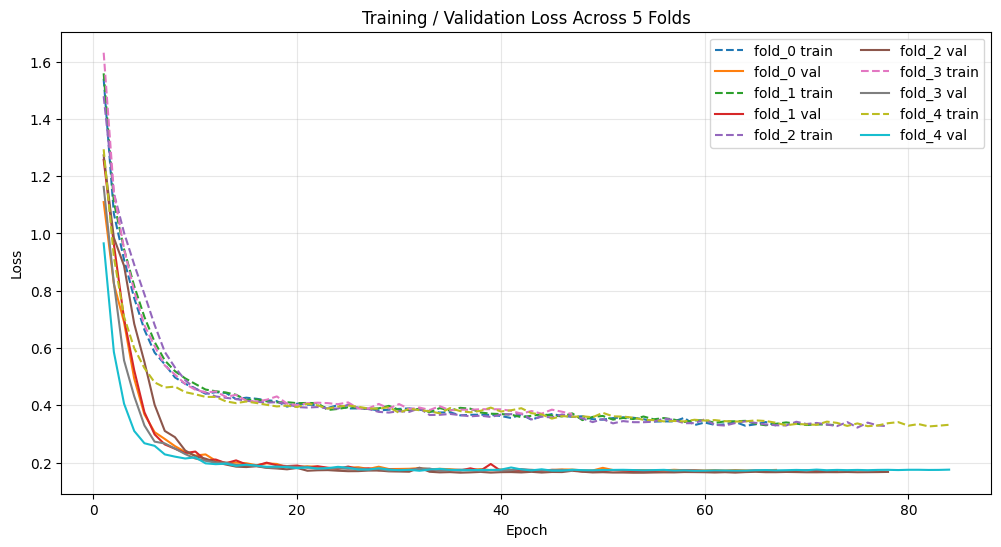

In [13]:
plt.figure(figsize=(12, 6))

for fold, df in all_df.groupby("fold"):
    plt.plot(df["epoch"], df["train_loss"], linestyle="--", label=f"{fold} train")
    plt.plot(df["epoch"], df["val_loss"], label=f"{fold} val")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss Across 5 Folds")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

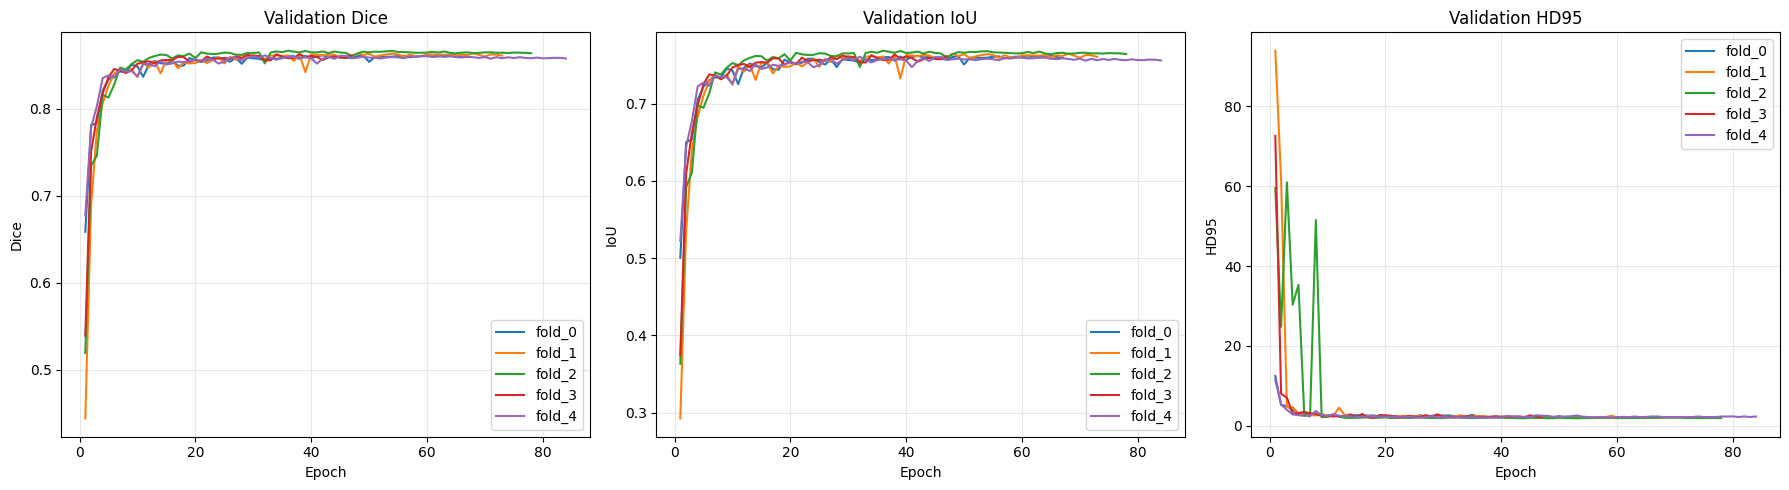

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for fold, df in all_df.groupby("fold"):
    axes[0].plot(df["epoch"], df["val_dice"], label=fold)
    axes[1].plot(df["epoch"], df["val_iou"], label=fold)
    axes[2].plot(df["epoch"], df["val_hd95"], label=fold)

axes[0].set_title("Validation Dice")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Dice")

axes[1].set_title("Validation IoU")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("IoU")

axes[2].set_title("Validation HD95")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("HD95")

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

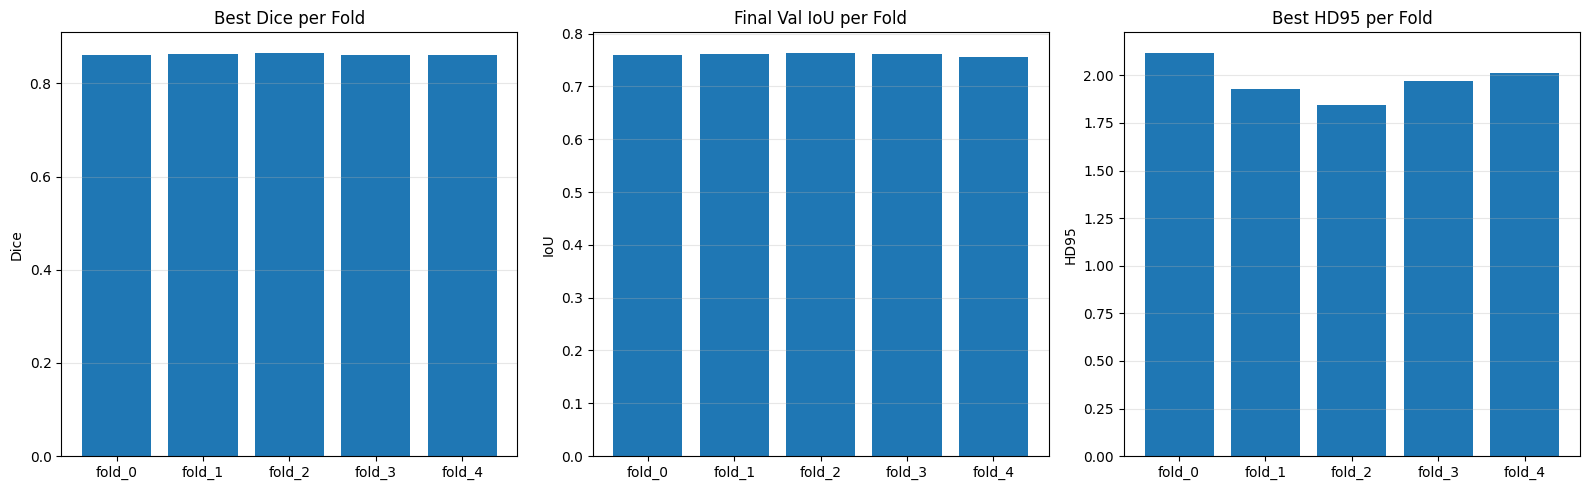

In [15]:
last_df = all_df.groupby("fold").tail(1).copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(last_df["fold"], last_df["best_dice"])
axes[0].set_title("Best Dice per Fold")
axes[0].set_ylabel("Dice")

axes[1].bar(last_df["fold"], last_df["val_iou"])
axes[1].set_title("Final Val IoU per Fold")
axes[1].set_ylabel("IoU")

axes[2].bar(last_df["fold"], last_df["best_hd95"])
axes[2].set_title("Best HD95 per Fold")
axes[2].set_ylabel("HD95")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

checkpoint = torch.load(
    "/kaggle/working/best_model_reunetplusplus_f3.pt",
    map_location=device
)

model.load_state_dict(checkpoint["model_state"])
model.to(device)
model.eval()
data_root = Path(r"/kaggle/input/datasets/helloworldabc/cubs-k-fold-dataset/data_cropped")
val_list = "/kaggle/input/datasets/helloworldabc/cubs-k-fold-dataset/data_cropped/Folds/f0/ValList.txt"
val_data = CUBSDataset(
    data_root=data_root,
    list_file=val_list,
    transform=val_transform,
)
image, mask = val_data[0]

if isinstance(image, np.ndarray):
    image = torch.from_numpy(image.astype("float32"))
else:
    image = image.float()

# image sau val_transform thuong da la [C, H, W]
if image.ndim == 2:
    image = image.unsqueeze(0)

image = image.unsqueeze(0).to(device)  # [1, C, H, W]

# warmup
with torch.no_grad():
    for _ in range(10):
        _ = model(image)

if device.type == "cuda":
    torch.cuda.synchronize()

# do trung binh nhieu lan
n_runs = 100

with torch.no_grad():
    if device.type == "cuda":
        starter = torch.cuda.Event(enable_timing=True)
        ender = torch.cuda.Event(enable_timing=True)

        starter.record()
        for _ in range(n_runs):
            logits = model(image)
        ender.record()

        torch.cuda.synchronize()
        infer_time_ms = starter.elapsed_time(ender) / n_runs
        infer_time_s = infer_time_ms / 1000.0

    else:
        start = time.perf_counter()
        for _ in range(n_runs):
            logits = model(image)
        end = time.perf_counter()

        infer_time_s = (end - start) / n_runs
        infer_time_ms = infer_time_s * 1000

print(f"Inference time: {infer_time_s:.6f} s/image")
print(f"Inference time: {infer_time_ms:.3f} ms/image")
print(f"FPS: {1 / infer_time_s:.2f}")

Inference time: 0.016539 s/image
Inference time: 16.539 ms/image
FPS: 60.46


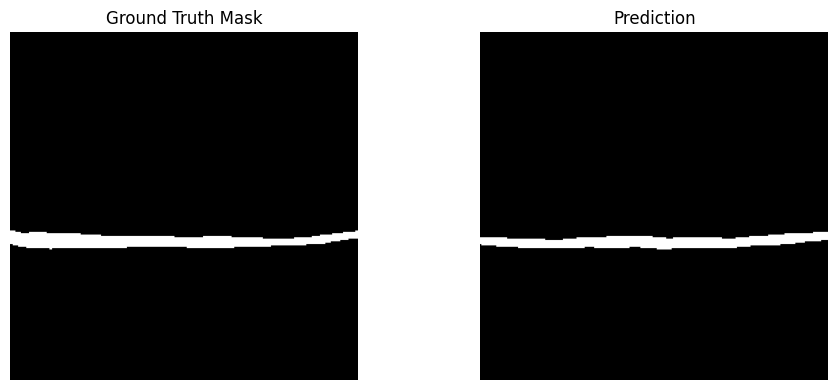

In [17]:
pred = logits.argmax(dim=1).detach().cpu().numpy()[0]

if torch.is_tensor(mask):
    mask_show = mask.detach().cpu().numpy()
else:
    mask_show = np.asarray(mask)

mask_show = np.squeeze(mask_show)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(mask_show, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pred, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# =========================
# K-fold test metrics + Bland-Altman plot
# =========================

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

from monai.metrics.meandice import DiceMetric
from monai.metrics.meaniou import MeanIoU
from monai.metrics import HausdorffDistanceMetric


def read_cf_um_per_pixel(cf_dir, image_stem):
    cf_path = Path(cf_dir) / f"{image_stem}_CF.txt"

    if not cf_path.is_file():
        raise FileNotFoundError(f"CF file not found: {cf_path}")

    return float(cf_path.read_text().strip()) * 1000.0


def mask_to_li_ma(mask):
    mask = np.squeeze(mask)
    mask = np.asarray(mask) > 0

    h, w = mask.shape

    li = np.full(w, np.nan, dtype=np.float32)
    ma = np.full(w, np.nan, dtype=np.float32)

    for x in range(w):
        ys = np.flatnonzero(mask[:, x])

        if ys.size > 0:
            li[x] = ys.min()
            ma[x] = ys.max()

    return li, ma


def boundary_errors_from_masks(pred_mask, gt_mask, um_per_pixel):
    pred_li, pred_ma = mask_to_li_ma(pred_mask)
    gt_li, gt_ma = mask_to_li_ma(gt_mask)

    valid = ~(
        np.isnan(pred_li)
        | np.isnan(pred_ma)
        | np.isnan(gt_li)
        | np.isnan(gt_ma)
    )

    valid_x = np.where(valid)[0]

    if valid.sum() == 0:
        return {
            "column_index": np.array([]),
            "li_pred_um": np.array([]),
            "li_gt_um": np.array([]),
            "ma_pred_um": np.array([]),
            "ma_gt_um": np.array([]),
            "imt_pred_um": np.array([]),
            "imt_gt_um": np.array([]),
            "li_signed_error_um": np.array([]),
            "ma_signed_error_um": np.array([]),
            "imt_signed_error_um": np.array([]),
            "li_abs_error_um": np.array([]),
            "ma_abs_error_um": np.array([]),
            "imt_abs_error_um": np.array([]),
        }

    li_pred_um = pred_li[valid] * um_per_pixel
    li_gt_um = gt_li[valid] * um_per_pixel

    ma_pred_um = pred_ma[valid] * um_per_pixel
    ma_gt_um = gt_ma[valid] * um_per_pixel

    imt_pred_um = (pred_ma[valid] - pred_li[valid]) * um_per_pixel
    imt_gt_um = (gt_ma[valid] - gt_li[valid]) * um_per_pixel

    li_signed_error_um = li_pred_um - li_gt_um
    ma_signed_error_um = ma_pred_um - ma_gt_um
    imt_signed_error_um = imt_pred_um - imt_gt_um

    return {
        "column_index": valid_x,
        "li_pred_um": li_pred_um,
        "li_gt_um": li_gt_um,
        "ma_pred_um": ma_pred_um,
        "ma_gt_um": ma_gt_um,
        "imt_pred_um": imt_pred_um,
        "imt_gt_um": imt_gt_um,
        "li_signed_error_um": li_signed_error_um,
        "ma_signed_error_um": ma_signed_error_um,
        "imt_signed_error_um": imt_signed_error_um,
        "li_abs_error_um": np.abs(li_signed_error_um),
        "ma_abs_error_um": np.abs(ma_signed_error_um),
        "imt_abs_error_um": np.abs(imt_signed_error_um),
    }


def safe_nanmean(values):
    values = np.asarray(values, dtype=np.float32)

    if values.size == 0:
        return np.nan

    return np.nanmean(values)


def plot_bland_altman_imt(error_df, title, output_path=None):
    imt_pred_mm = pd.to_numeric(error_df["imt_pred_um"], errors="coerce") / 1000.0
    imt_gt_mm = pd.to_numeric(error_df["imt_gt_um"], errors="coerce") / 1000.0

    valid = ~(imt_pred_mm.isna() | imt_gt_mm.isna())

    imt_pred_mm = imt_pred_mm[valid]
    imt_gt_mm = imt_gt_mm[valid]

    average_mm = (imt_pred_mm + imt_gt_mm) / 2.0
    difference_mm = imt_pred_mm - imt_gt_mm

    mean_diff = difference_mm.mean()
    sd_diff = difference_mm.std(ddof=1)

    upper_loa = mean_diff + 1.96 * sd_diff
    lower_loa = mean_diff - 1.96 * sd_diff

    rpc = 1.96 * sd_diff
    rpc_percent = rpc / average_mm.mean() * 100.0

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.scatter(
        average_mm,
        difference_mm,
        s=18,
        marker="s",
        facecolors="none",
        edgecolors="#2f5fb3",
        alpha=0.65,
        linewidths=0.9,
    )

    ax.axhline(mean_diff, color="gray", linestyle="-", linewidth=1.5)
    ax.axhline(upper_loa, color="gray", linestyle=":", linewidth=1.5)
    ax.axhline(lower_loa, color="gray", linestyle=":", linewidth=1.5)

    x_text = average_mm.max() * 0.82

    ax.text(
        average_mm.mean(),
        difference_mm.max() * 0.88,
        f"RPC: {rpc:.2f} ({rpc_percent:.0f}%)",
        fontsize=13,
        fontweight="bold",
        ha="center",
    )

    ax.text(
        x_text,
        upper_loa,
        f"{upper_loa:.2f} (+1.96SD)",
        fontsize=12,
        va="bottom",
    )

    ax.text(
        x_text,
        mean_diff,
        f"{mean_diff:.2f}",
        fontsize=12,
        va="bottom",
    )

    ax.text(
        x_text,
        lower_loa,
        f"{lower_loa:.2f} (-1.96SD)",
        fontsize=12,
        va="top",
    )

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("cIMT average (prediction + ground truth) / 2 (mm)")
    ax.set_ylabel("cIMT difference (prediction - ground truth) (mm)")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()


def plot_bland_altman_imt_by_fold(error_distribution, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for fold_name, fold_df in error_distribution.groupby("fold"):
        output_path = output_dir / f"bland_altman_imt_{fold_name}.png"

        plot_bland_altman_imt(
            error_df=fold_df,
            title=f"Bland-Altman CIMT - {fold_name}",
            output_path=output_path,
        )


def masks_to_onehot(mask, num_classes=2):
    if mask.ndim == 4:
        mask = mask.squeeze(1)

    mask = mask.long()

    one_hot = F.one_hot(mask, num_classes=num_classes)
    one_hot = one_hot.permute(0, 3, 1, 2).float()

    return one_hot


def metric_value(metric):
    value = metric.aggregate()
    metric.reset()

    if isinstance(value, torch.Tensor):
        value = value.detach().cpu().numpy()

    return float(np.nanmean(value))


def mean_std(values):
    values = pd.to_numeric(pd.Series(values), errors="coerce")
    return values.mean(), values.std(ddof=1)


def load_model_state(model, ckpt_path, device):
    checkpoint = torch.load(ckpt_path, map_location=device)

    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        model.load_state_dict(checkpoint["model_state"])
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        model.load_state_dict(checkpoint["state_dict"])
    else:
        model.load_state_dict(checkpoint)

    return model


def evaluate_checkpoint_on_test(
    ckpt_path,
    data_root,
    test_list,
    cf_dir,
    batch_size=32,
    num_classes=2,
):
    test_data = CUBSDataset(
        data_root=data_root,
        list_file=test_list,
        transform=val_transform,
    )

    test_loader = DataLoader(
        test_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model = build_residual_aspp_unetplusplus().to(device)
    
    model = load_model_state(model, ckpt_path, device)
    model.eval()

    dice_metric = DiceMetric(include_background=False, reduction="mean")
    iou_metric = MeanIoU(include_background=False, reduction="mean")

    hd95_metric = HausdorffDistanceMetric(
        include_background=False,
        percentile=95,
        directed=False,
        reduction="mean",
        get_not_nans=False,
    )

    li_mae_values = []
    ma_mae_values = []
    imt_mae_values = []

    error_rows = []

    sample_offset = 0

    with torch.no_grad():
        for images, masks in tqdm(
            test_loader,
            desc=f"Testing {Path(ckpt_path).stem}",
            leave=False,
        ):
            images = images.to(device).float()
            masks = masks.to(device).long()

            logits = get_logits(model, images)
            preds = torch.argmax(logits, dim=1)

            pred_oh = masks_to_onehot(preds, num_classes=num_classes)
            true_oh = masks_to_onehot(masks, num_classes=num_classes)

            dice_metric(pred_oh, true_oh)
            iou_metric(pred_oh, true_oh)
            hd95_metric(pred_oh.cpu(), true_oh.cpu())

            batch_size_actual = preds.shape[0]

            for i in range(batch_size_actual):
                image_stem = test_data.images[sample_offset + i].stem
                um_per_pixel = read_cf_um_per_pixel(cf_dir, image_stem)

                errors = boundary_errors_from_masks(
                    pred_mask=preds[i].detach().cpu().numpy(),
                    gt_mask=masks[i].detach().cpu().numpy(),
                    um_per_pixel=um_per_pixel,
                )

                li_mae_values.append(safe_nanmean(errors["li_abs_error_um"]))
                ma_mae_values.append(safe_nanmean(errors["ma_abs_error_um"]))
                imt_mae_values.append(safe_nanmean(errors["imt_abs_error_um"]))

                n_cols = len(errors["column_index"])

                for j in range(n_cols):
                    error_rows.append(
                        {
                            "image_stem": image_stem,
                            "column_index": int(errors["column_index"][j]),

                            "li_pred_um": errors["li_pred_um"][j],
                            "li_gt_um": errors["li_gt_um"][j],
                            "ma_pred_um": errors["ma_pred_um"][j],
                            "ma_gt_um": errors["ma_gt_um"][j],
                            "imt_pred_um": errors["imt_pred_um"][j],
                            "imt_gt_um": errors["imt_gt_um"][j],

                            "li_signed_error_um": errors["li_signed_error_um"][j],
                            "ma_signed_error_um": errors["ma_signed_error_um"][j],
                            "imt_signed_error_um": errors["imt_signed_error_um"][j],
                            "li_abs_error_um": errors["li_abs_error_um"][j],
                            "ma_abs_error_um": errors["ma_abs_error_um"][j],
                            "imt_abs_error_um": errors["imt_abs_error_um"][j],
                        }
                    )

            sample_offset += batch_size_actual

    metrics = {
        "dice": metric_value(dice_metric),
        "iou": metric_value(iou_metric),
        "hd95": metric_value(hd95_metric),
        "li_mae": np.nanmean(li_mae_values),
        "ma_mae": np.nanmean(ma_mae_values),
        "imt_mae": np.nanmean(imt_mae_values),
    }

    error_df = pd.DataFrame(error_rows)

    return metrics, error_df


def find_checkpoint(checkpoint_dir, fold_name):
    checkpoint_dir = Path(checkpoint_dir)

    candidates = [
        checkpoint_dir / f"best_model_reunetplusplus_{fold_name}.pt",
    ]

    if fold_name.startswith("f"):
        fold_idx = fold_name[1:]
        candidates.append(
            checkpoint_dir / f"best_model_reunetplusplus_fold_{fold_idx}.pt"
        )

    for path in candidates:
        if path.is_file():
            return path

    raise FileNotFoundError(
        "Cannot find checkpoint. Tried:\n"
        + "\n".join(str(p) for p in candidates)
    )


def evaluate_kfold_test_metrics(
    data_root,
    checkpoint_dir,
    batch_size=32,
    num_classes=2,
):
    data_root = Path(data_root)
    checkpoint_dir = Path(checkpoint_dir)

    kfold_root = data_root / "Folds"
    cf_dir = data_root / "CF"

    if not kfold_root.is_dir():
        raise FileNotFoundError(f"Folds folder not found: {kfold_root}")

    if not cf_dir.is_dir():
        raise FileNotFoundError(f"CF folder not found: {cf_dir}")

    fold_dirs = sorted(
        p for p in kfold_root.iterdir()
        if p.is_dir() and p.name.startswith("f")
    )

    if not fold_dirs:
        raise RuntimeError(f"No fold folders found in: {kfold_root}")

    rows = []
    all_error_dfs = []

    for fold_dir in fold_dirs:
        fold_name = fold_dir.name
        test_list = fold_dir / "TestList.txt"

        if not test_list.is_file():
            raise FileNotFoundError(f"Test list not found: {test_list}")

        ckpt_path = find_checkpoint(checkpoint_dir, fold_name)

        print(f"\n===== Testing {fold_name} =====")
        print(f"Checkpoint: {ckpt_path}")
        print(f"Test list : {test_list}")

        row, fold_error_df = evaluate_checkpoint_on_test(
            ckpt_path=ckpt_path,
            data_root=data_root,
            test_list=test_list,
            cf_dir=cf_dir,
            batch_size=batch_size,
            num_classes=num_classes,
        )

        row["fold"] = fold_name
        rows.append(row)

        fold_error_df["fold"] = fold_name
        all_error_dfs.append(fold_error_df)

    per_fold = pd.DataFrame(rows)

    metric_names = {
        "imt_mae": "CIMT/IMT MAE",
        "li_mae": "LI MAE",
        "ma_mae": "MA MAE",
        "dice": "Dice",
        "iou": "IoU",
        "hd95": "HD95",
    }

    metric_units = {
        "imt_mae": "um",
        "li_mae": "um",
        "ma_mae": "um",
        "dice": "",
        "iou": "",
        "hd95": "pixel",
    }

    summary_rows = []

    for metric in metric_names:
        mean, std = mean_std(per_fold[metric])

        summary_rows.append(
            {
                "metric": metric_names[metric],
                "unit": metric_units[metric],
                "mean": mean,
                "std": std,
                "mean_std": f"{mean:.4f} +- {std:.4f}",
            }
        )

    summary = pd.DataFrame(summary_rows)

    error_distribution = pd.concat(all_error_dfs, ignore_index=True)

    per_fold_path = checkpoint_dir / "kfold_test_metrics_per_fold.csv"
    summary_path = checkpoint_dir / "kfold_test_metrics_mean_std.csv"
    error_distribution_path = checkpoint_dir / "kfold_error_distribution_by_column.csv"

    bland_altman_all_path = checkpoint_dir / "bland_altman_imt_all_folds.png"
    bland_altman_fold_dir = checkpoint_dir / "bland_altman_by_fold"

    per_fold.to_csv(per_fold_path, index=False)
    summary.to_csv(summary_path, index=False)
    error_distribution.to_csv(error_distribution_path, index=False)

    plot_bland_altman_imt(
        error_df=error_distribution,
        title="Bland-Altman CIMT - All folds",
        output_path=bland_altman_all_path,
    )

    plot_bland_altman_imt_by_fold(
        error_distribution=error_distribution,
        output_dir=bland_altman_fold_dir,
    )

    print(f"\nSaved per-fold metrics to       : {per_fold_path}")
    print(f"Saved summary metrics to        : {summary_path}")
    print(f"Saved error distribution to     : {error_distribution_path}")
    print(f"Saved Bland-Altman all folds to : {bland_altman_all_path}")
    print(f"Saved Bland-Altman by fold to   : {bland_altman_fold_dir}")

    return per_fold, summary, error_distribution


===== Testing f0 =====
Checkpoint: /kaggle/working/best_model_reunetplusplus_f0.pt
Test list : /kaggle/input/datasets/helloworldabc/cubs-k-fold-dataset/data_cropped/Folds/f0/TestList.txt


Testing best_model_reunetplusplus_f0:   0%|          | 0/17 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)



===== Testing f1 =====
Checkpoint: /kaggle/working/best_model_reunetplusplus_f1.pt
Test list : /kaggle/input/datasets/helloworldabc/cubs-k-fold-dataset/data_cropped/Folds/f1/TestList.txt


Testing best_model_reunetplusplus_f1:   0%|          | 0/17 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)



===== Testing f2 =====
Checkpoint: /kaggle/working/best_model_reunetplusplus_f2.pt
Test list : /kaggle/input/datasets/helloworldabc/cubs-k-fold-dataset/data_cropped/Folds/f2/TestList.txt


Testing best_model_reunetplusplus_f2:   0%|          | 0/17 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)



===== Testing f3 =====
Checkpoint: /kaggle/working/best_model_reunetplusplus_f3.pt
Test list : /kaggle/input/datasets/helloworldabc/cubs-k-fold-dataset/data_cropped/Folds/f3/TestList.txt


Testing best_model_reunetplusplus_f3:   0%|          | 0/17 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)



===== Testing f4 =====
Checkpoint: /kaggle/working/best_model_reunetplusplus_f4.pt
Test list : /kaggle/input/datasets/helloworldabc/cubs-k-fold-dataset/data_cropped/Folds/f4/TestList.txt


Testing best_model_reunetplusplus_f4:   0%|          | 0/17 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


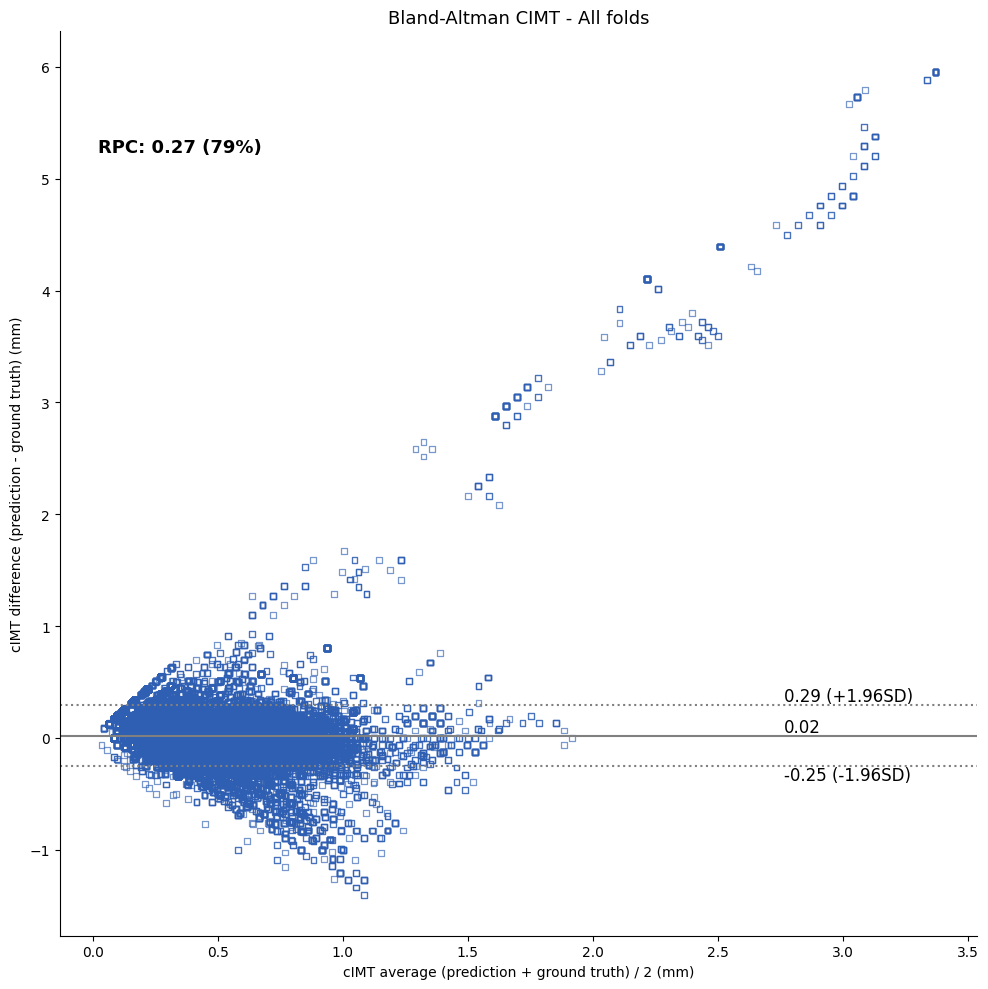

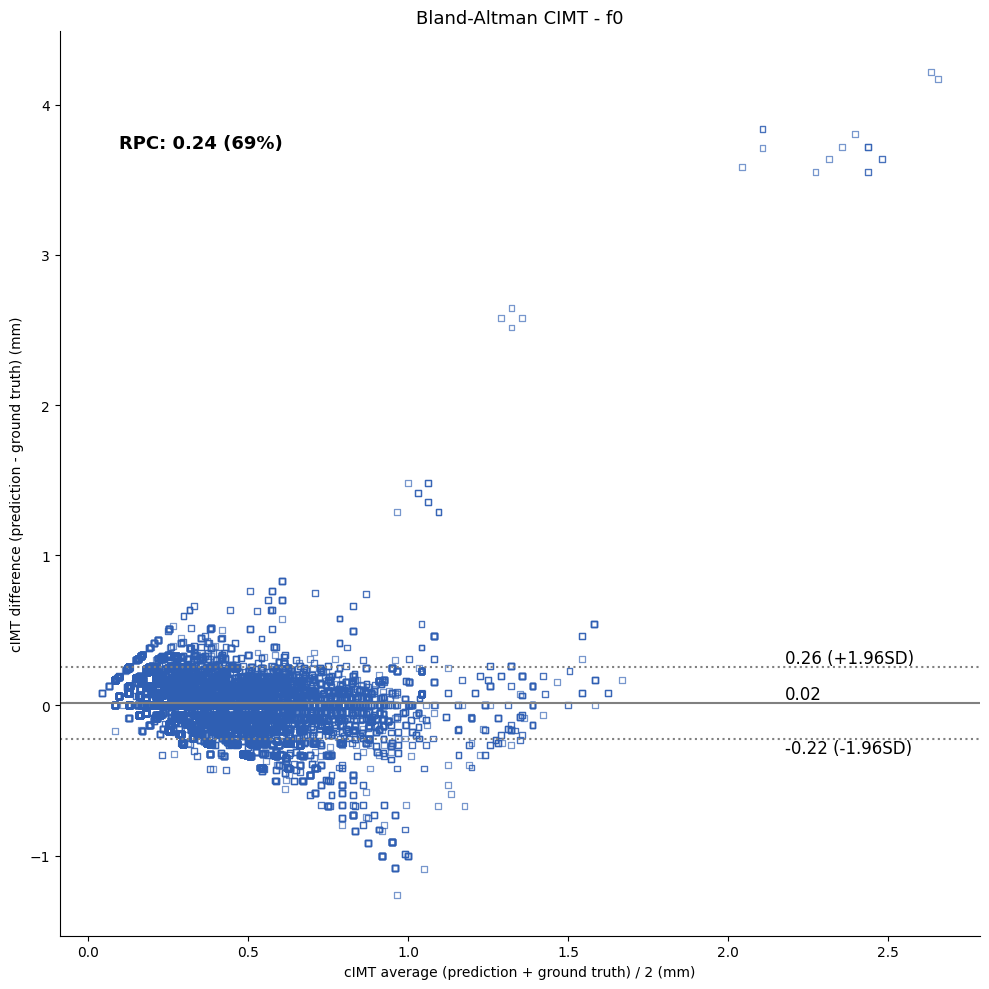

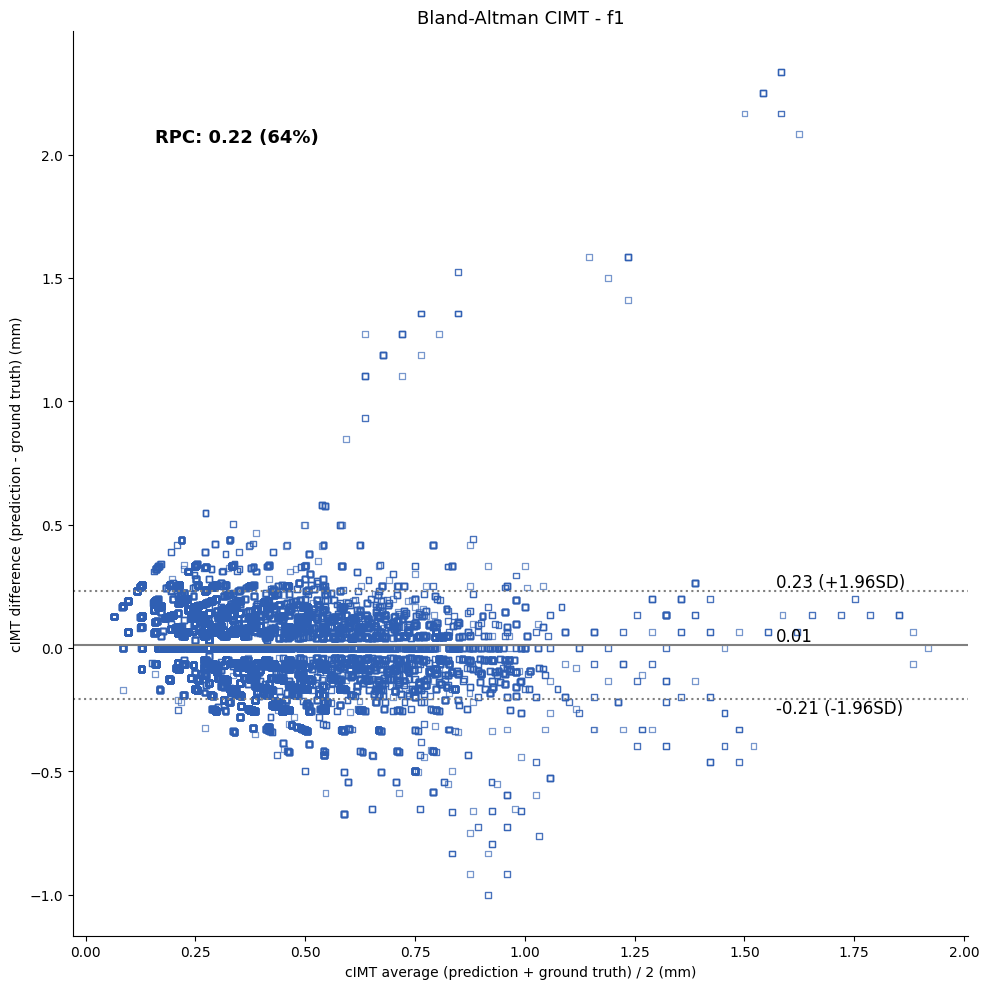

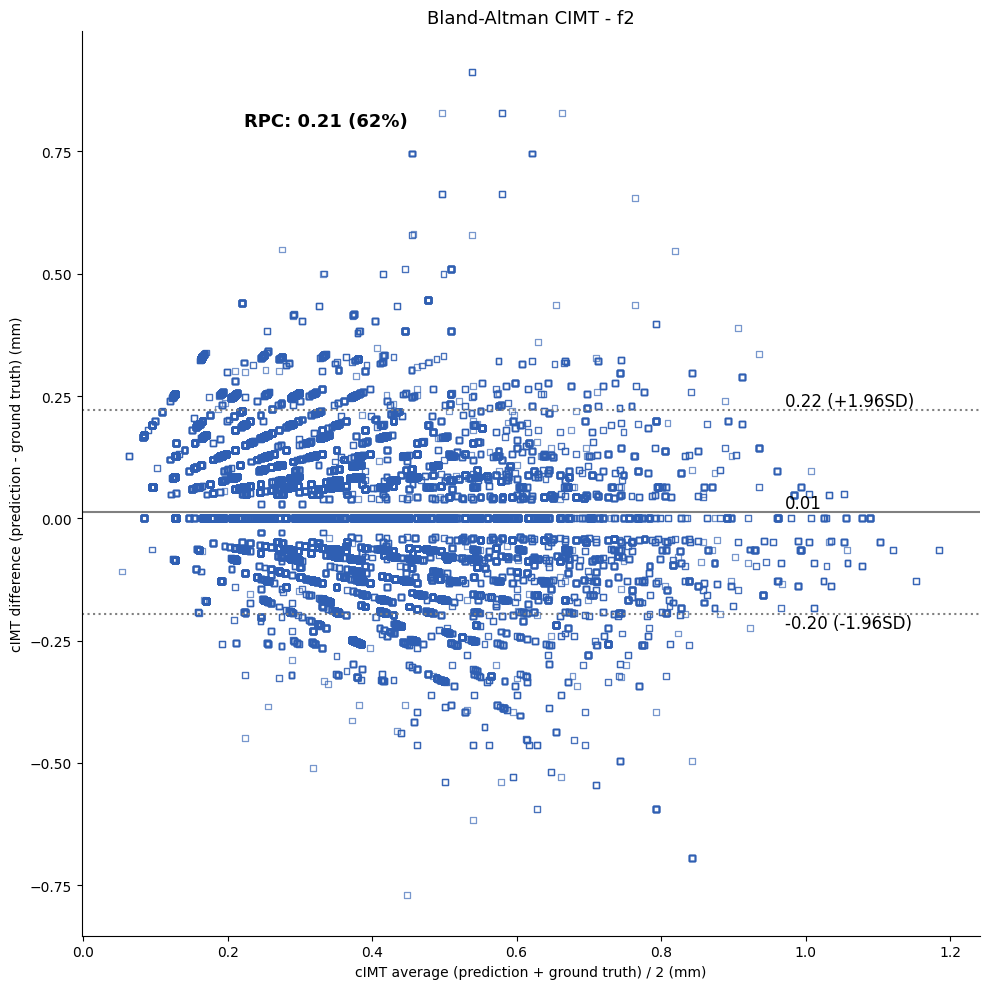

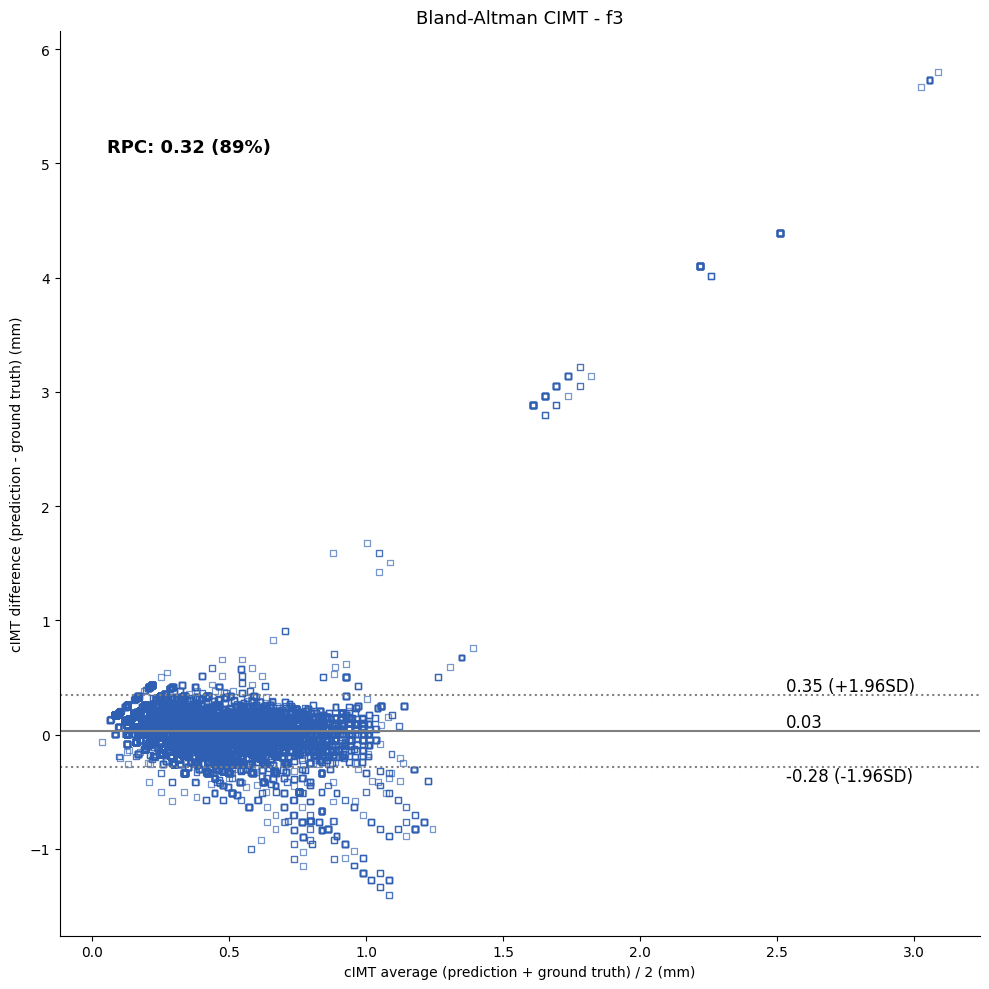

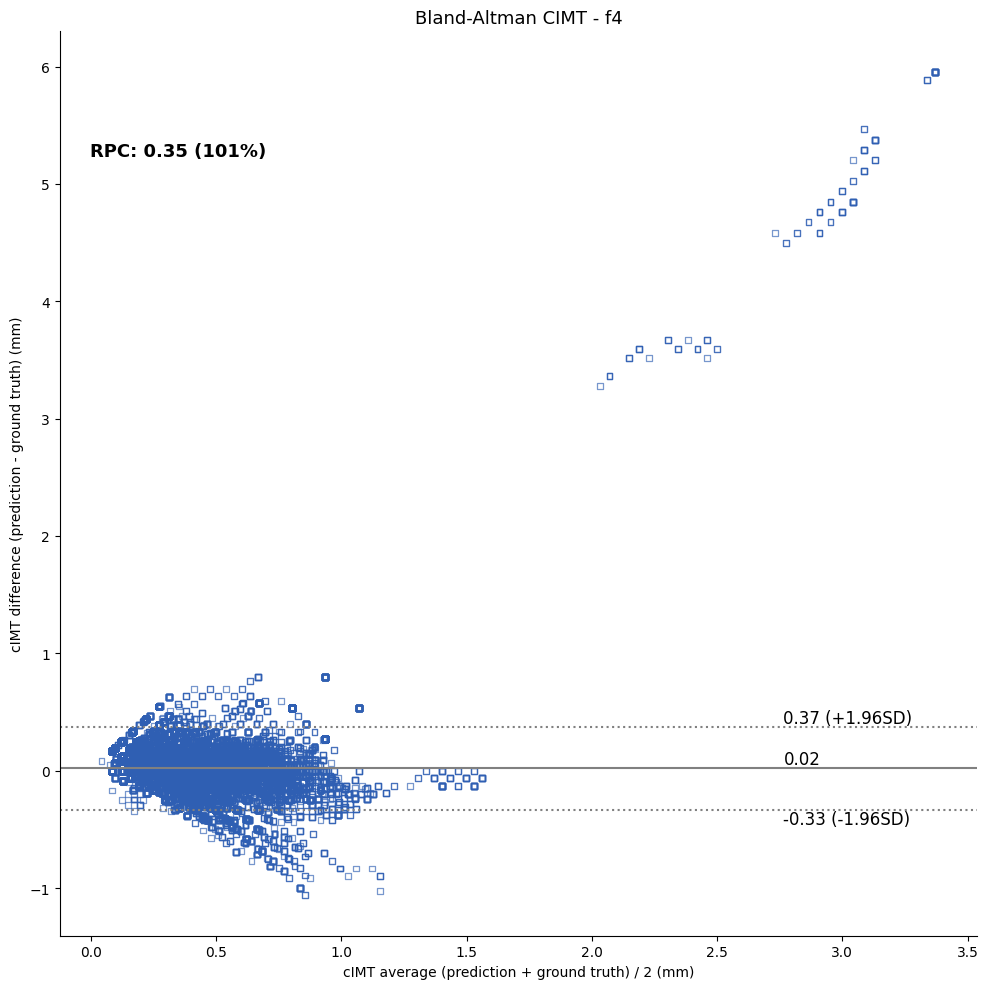


Saved per-fold metrics to       : /kaggle/working/kfold_test_metrics_per_fold.csv
Saved summary metrics to        : /kaggle/working/kfold_test_metrics_mean_std.csv
Saved error distribution to     : /kaggle/working/kfold_error_distribution_by_column.csv
Saved Bland-Altman all folds to : /kaggle/working/bland_altman_imt_all_folds.png
Saved Bland-Altman by fold to   : /kaggle/working/bland_altman_by_fold


In [19]:
data_root = Path(r"/kaggle/input/datasets/helloworldabc/cubs-k-fold-dataset/data_cropped")
checkpoint_dir = Path(r"/kaggle/working/")

per_fold, summary, error_distribution = evaluate_kfold_test_metrics(
    data_root=data_root,
    checkpoint_dir=checkpoint_dir,
    batch_size=32,
    num_classes=2,
)

In [20]:
display(per_fold)

,dice,iou,hd95,li_mae,ma_mae,imt_mae,fold
0,0.864917,0.765849,1.961838,60.227848,52.024334,83.889290,f0
1,0.865881,0.766848,1.843615,57.818661,50.261963,80.480690,f1
2,0.864016,0.764895,1.884939,56.741360,51.024174,78.687531,f2
3,0.857140,0.754179,2.226215,62.685013,57.568363,90.637375,f3
4,0.861561,0.761781,2.333304,61.297386,55.884968,88.198212,f4


In [21]:
display(summary)

,metric,unit,mean,std,mean_std
0,CIMT/IMT MAE,um,84.378616,5.039422,84.3786 +- 5.0394
1,LI MAE,um,59.754051,2.450457,59.7541 +- 2.4505
2,MA MAE,um,53.352760,3.198572,53.3528 +- 3.1986
3,Dice,,0.862703,0.003499,0.8627 +- 0.0035
4,IoU,,0.762710,0.005133,0.7627 +- 0.0051
5,HD95,pixel,2.049982,0.217328,2.0500 +- 0.2173
